# Exercise 09 – Sensor Data Analysis

Basic analysis of accelerometer data collected from Samsung SM-S928B using the SensorDataCollectorApp.

In [27]:
"""Exercise 09 – Sensor Data Analysis"""
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('data.json', encoding='utf-8') as f:
    raw = json.load(f)

print(f'Total data points: {len(raw)}')
print('Sample entry:')
print(json.dumps(raw[0], indent=2))

Total data points: 414
Sample entry:
{
  "id": "b4d7ca32-53e9-11f1-8709-00155d98138d",
  "patient_id": 3,
  "experiment_id": 3,
  "data": {
    "accuracy": 3,
    "data": [
      -0.038285162,
      2.2277179,
      9.667004
    ],
    "device": "samsung SM-S928B",
    "experimentId": 3,
    "friendlyTimeStamp": "2026-05-29 01:38:56.463",
    "patientId": 3,
    "sensorId": "lsm6dsv LSM6DSV Accelerometer Non-wakeup",
    "sensorType": 1,
    "timestamp": 1503838970221209
  }
}


In [28]:
records = []
for entry in raw:
    d = entry['data']
    records.append({
        'timestamp': d['timestamp'],
        'friendly_time': d['friendlyTimeStamp'],
        'sensor': d['sensorId'],
        'x': d['data'][0],
        'y': d['data'][1],
        'z': d['data'][2],
    })

df = pd.DataFrame(records)
df = df.sort_values('timestamp').reset_index(drop=True)
print(df.head())

          timestamp            friendly_time  \
0  1503838927216522  2026-05-29 01:38:56.420   
1  1503838935817459  2026-05-29 01:38:56.428   
2  1503838944418397  2026-05-29 01:38:56.437   
3  1503838953019334  2026-05-29 01:38:56.446   
4  1503838961620272  2026-05-29 01:38:56.454   

                                     sensor         x         y         z  
0  lsm6dsv LSM6DSV Accelerometer Non-wakeup -0.124427  2.249253  9.611969  
1  lsm6dsv LSM6DSV Accelerometer Non-wakeup -0.112463  2.225325  9.726824  
2  lsm6dsv LSM6DSV Accelerometer Non-wakeup -0.093320  2.230111  9.616755  
3  lsm6dsv LSM6DSV Accelerometer Non-wakeup -0.059821  2.242075  9.525827  
4  lsm6dsv LSM6DSV Accelerometer Non-wakeup -0.047856  2.246860  9.597611  


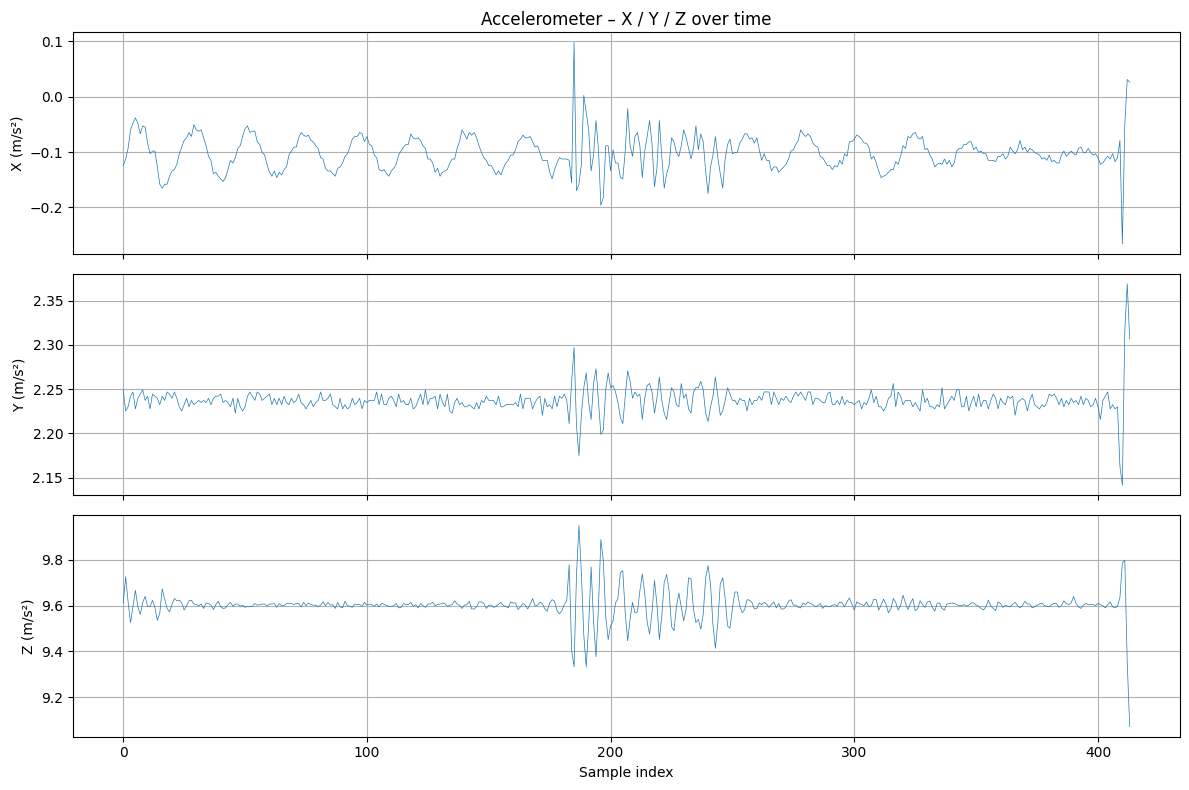

Plot saved as img/accelerometer_plot.png


In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, axis in zip(axes, ['x', 'y', 'z']):
    ax.plot(df.index, df[axis], linewidth=0.5)
    ax.set_ylabel(f'{axis.upper()} (m/s²)')
    ax.grid(True)

axes[0].set_title('Accelerometer – X / Y / Z over time')
axes[2].set_xlabel('Sample index')
plt.tight_layout()
plt.savefig('img/accelerometer_plot.png', dpi=150)
plt.show()
print('Plot saved as img/accelerometer_plot.png')

In [30]:
print('Basic statistics:')
print(df[['x', 'y', 'z']].describe())

Basic statistics:
                x           y           z
count  414.000000  414.000000  414.000000
mean    -0.101764    2.237197    9.602374
std      0.031879    0.014250    0.061702
min     -0.265603    2.141576    9.071191
25%     -0.122034    2.232503    9.592826
50%     -0.102891    2.237289    9.604790
75%     -0.081356    2.242075    9.611969
max      0.098106    2.368894    9.951750


## Magnitude (Total Acceleration)

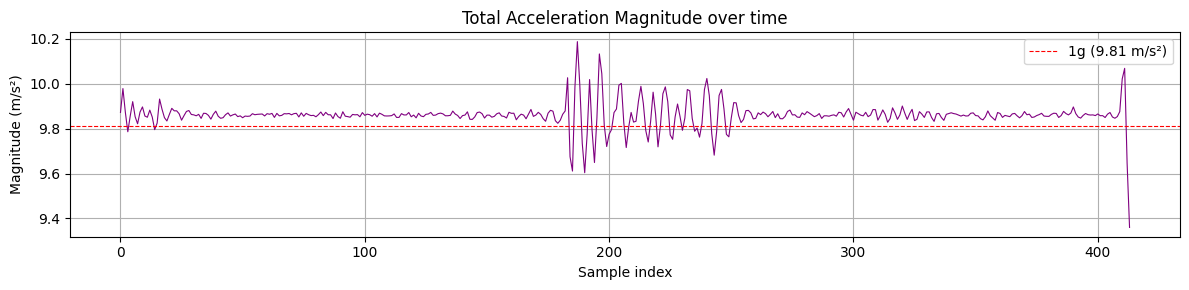

Mean magnitude: 9.8602 m/s²
Std magnitude:  0.0581 m/s²


In [31]:
import numpy as np

df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

plt.figure(figsize=(12, 3))
plt.plot(df.index, df['magnitude'], linewidth=0.8, color='purple')
plt.axhline(y=9.81, color='red', linestyle='--', linewidth=0.8, label='1g (9.81 m/s²)')
plt.ylabel('Magnitude (m/s²)')
plt.xlabel('Sample index')
plt.title('Total Acceleration Magnitude over time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('img/magnitude_plot.png', dpi=150)
plt.show()
print(f'Mean magnitude: {df["magnitude"].mean():.4f} m/s²')
print(f'Std magnitude:  {df["magnitude"].std():.4f} m/s²')

## FFT Frequency Analysis

Removing gravity (DC component) and applying FFT to detect dominant movement frequencies.
Parkinson's disease tremors typically appear in the **4–6 Hz** range.

Sampling rate: 116.3 Hz


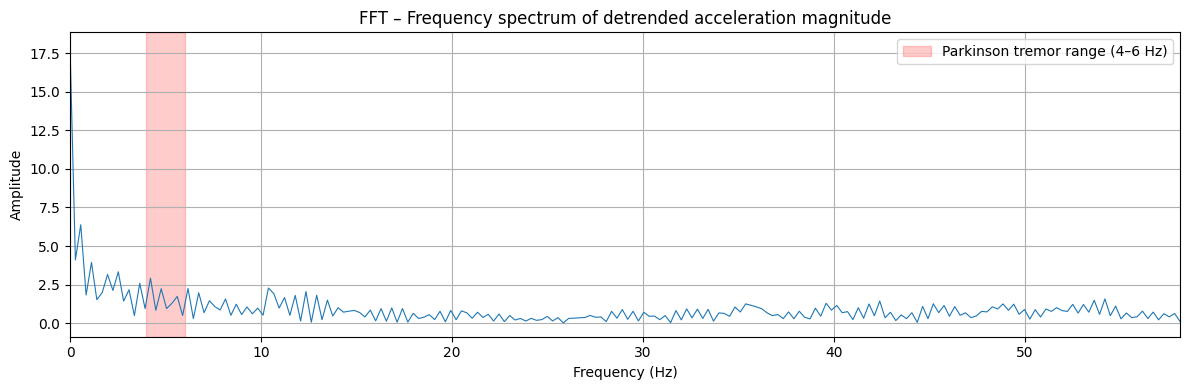

Dominant frequency: 0.00 Hz


In [32]:
# Sampling rate from timestamps (nanoseconds → Hz)
ts = df['timestamp'].values
dt_ns = np.diff(ts).mean()
fs = 1e9 / dt_ns
print(f'Sampling rate: {fs:.1f} Hz')

# Remove gravity (subtract mean per axis = detrend)
for axis in ['x', 'y', 'z']:
    df[f'{axis}_detrended'] = df[axis] - df[axis].mean()

# FFT on magnitude of detrended signal
mag_detrended = np.sqrt(df['x_detrended']**2 + df['y_detrended']**2 + df['z_detrended']**2)
n = len(mag_detrended)
freqs = np.fft.rfftfreq(n, d=1/fs)
fft_vals = np.abs(np.fft.rfft(mag_detrended))

plt.figure(figsize=(12, 4))
plt.plot(freqs, fft_vals, linewidth=0.8)
plt.axvspan(4, 6, alpha=0.2, color='red', label='Parkinson tremor range (4–6 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT – Frequency spectrum of detrended acceleration magnitude')
plt.xlim(0, fs / 2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('img/fft_plot.png', dpi=150)
plt.show()

peak_freq = freqs[np.argmax(fft_vals)]
print(f'Dominant frequency: {peak_freq:.2f} Hz')